<a href="https://colab.research.google.com/github/MohammadRezaNamvarNejad/ABSA-LLM/blob/main/Copy_of_Gemma_2_2B_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# 0. Install deps (leave default PyTorch alone)
# ==========================================
!pip install -q -U transformers accelerate bitsandbytes sentence-transformers faiss-cpu

import torch
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import gc
import re
from sentence_transformers import SentenceTransformer
import faiss
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# check GPU
if torch.cuda.is_available():
    print("✅ GPU is active:", torch.cuda.get_device_name(0))
else:
    print("GPU not active — Runtime > Change runtime type > T4 GPU")

# free GPU memory before starting
torch.cuda.empty_cache()
gc.collect()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 49.6 MB/s eta 0:00:00
✅ GPU is active: Tesla T4


60

In [2]:
# ==========================================
# 1. Data pipeline
# ==========================================
xml_filename = "ABSA16_Restaurants_Train_SB1_v2.xml"

def parse_xml_safe(file_path):
    dataset = []
    try:
        tree = ET.parse(file_path)
        for review in tree.getroot().findall('Review'):
            sentences = review.find('sentences')
            if sentences is None: continue
            for sentence in sentences.findall('sentence'):
                text = sentence.find('text').text
                opinions = sentence.find('Opinions')
                if opinions is None: continue
                for opinion in opinions.findall('Opinion'):
                    if opinion.get('polarity') == "conflict": continue
                    dataset.append({
                        "text": text,
                        "aspect": opinion.get('category'),
                        "true_label": opinion.get('polarity')
                    })
        return dataset
    except Exception as e:
        print(f"Error parsing XML: {e}")
        return []

In [4]:
# try loading the XML file
full_data = parse_xml_safe(xml_filename)

if full_data:
    split = int(len(full_data) * 0.9)
    training_set = full_data[:split]
    testing_set = full_data[split:][:50]
    print(f"Loaded data — train: {len(training_set)} | test: {len(testing_set)}")
else:
    print("XML not found; using dummy data.")
    training_set = [{"text": "Great food.", "aspect": "FOOD#QUALITY", "true_label": "positive"}] * 5
    testing_set = [{"text": "Bad service.", "aspect": "SERVICE#GENERAL", "true_label": "negative"}]

# build FAISS index with all-MiniLM-L6-v2
encoder = SentenceTransformer('all-MiniLM-L6-v2')
index = faiss.IndexFlatL2(384)
if training_set:
    embeddings = encoder.encode([d['text'] for d in training_set])
    index.add(np.array(embeddings))

def retrieve_rag(query, k=3):
    if not training_set: return []
    q_emb = encoder.encode([query])
    _, idxs = index.search(np.array(q_emb), k)
    return [training_set[i] for i in idxs[0]]

✅ داده‌ها لود شد. آموزش: 2256 | تست: 50


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [5]:
# ==========================================
# 2. Prompts and label parsing
# ==========================================

def generate_unified_prompt(method, sample):
    base_instruction = (
        "Task: Aspect-Based Sentiment Analysis (ABSA) on Restaurant Reviews.\n"
        "Classify the sentiment polarity of the target aspect into exactly one of these labels: positive, negative, or neutral.\n"
    )

    if method == "Zero-Shot":
        content = (
            base_instruction +
            f"Sentence: \"{sample['text']}\"\n"
            f"Target Aspect: \"{sample['aspect']}\"\n"
            "Output ONLY the final sentiment label in lowercase."
        )

    elif method == "One-Shot":
        content = (
            base_instruction +
            "Output ONLY the final sentiment label in lowercase.\n"
            "Example:\n"
            "Sentence: \"The food was absolutely delicious, but the service was terrible.\"\n"
            "Target Aspect: \"food\"\n"
            "Sentiment: positive\n"
            "Now classify the following:\n"
            f"Sentence: \"{sample['text']}\"\n"
            f"Target Aspect: \"{sample['aspect']}\"\n"
            "Sentiment:"
        )

    elif method == "RAG":
        rets = retrieve_rag(sample['text'], k=3)
        retrieved_examples = ""
        # always pad to exactly 3 shots
        if len(rets) == 3:
            retrieved_examples = (
                f"Sentence: \"{rets[0]['text']}\" | Target Aspect: \"{rets[0]['aspect']}\" -> Sentiment: {rets[0]['true_label']}\n"
                f"Sentence: \"{rets[1]['text']}\" | Target Aspect: \"{rets[1]['aspect']}\" -> Sentiment: {rets[1]['true_label']}\n"
                f"Sentence: \"{rets[2]['text']}\" | Target Aspect: \"{rets[2]['aspect']}\" -> Sentiment: {rets[2]['true_label']}\n"
            )

        content = (
            base_instruction +
            "Output ONLY the final sentiment label in lowercase.\n"
            "Here are some reference examples:\n" +
            retrieved_examples +
            "Now classify the following:\n"
            f"Sentence: \"{sample['text']}\"\n"
            f"Target Aspect: \"{sample['aspect']}\"\n"
            "Sentiment:"
        )

    # put everything in the user role (no system prompt)
    return [{"role": "user", "content": content}]

def clean_output_label(text):
    """
    Strip extra text and return one of the three labels.
    """
    text = text.lower().strip()
    match = re.search(r'\b(positive|negative|neutral)\b', text)
    if match:
        return match.group(1)
    return "neutral"  # fallback when parsing fails

In [7]:
from huggingface_hub import login

# paste your HF token here
login("YOUR_TOKEN")

In [9]:
# ==========================================
# 3. Run model
# ==========================================
import traceback  # for full stack traces on errors
model_name = "google/gemma-2-2b-it"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print(f"\nRunning {model_name}...")
gemma_results = []

try:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")
    print("Model loaded.")

    for method in ["Zero-Shot", "One-Shot", "RAG"]:
        print(f"  Running {method}...")
        correct = 0
        total = 0
        error_printed = False

        for sample in testing_set:
            try:
                msgs = generate_unified_prompt(method, sample)

                # tokenize chat template -> input_ids + attention_mask
                prompt_text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
                inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)

                with torch.no_grad():
                    # forward full inputs; no temperature arg
                    outputs = model.generate(
                        **inputs,
                        max_new_tokens=5,
                        do_sample=False
                    )

                # decode only newly generated tokens
                input_length = inputs["input_ids"].shape[-1]
                generated_ids = outputs[0][input_length:]
                decoded = tokenizer.decode(generated_ids, skip_special_tokens=True)

                # parse and normalize label
                pred = clean_output_label(decoded)

                if pred == sample['true_label']: correct += 1
                total += 1

            except Exception as inner_e:
                if not error_printed:
                    # log full traceback on failure
                    print(f"    ❌ Error Detail:\n{traceback.format_exc()}")
                    error_printed = True
                continue

        acc = (correct / total) * 100 if total > 0 else 0
        print(f"    -> Accuracy: {acc:.2f}%")
        gemma_results.append({"Model": "Gemma-2-2B", "Method": method, "Accuracy": acc})

except Exception as e:
    print(f"\nCRITICAL ERROR: {e}")

# print benchmark summary
print("\nBenchmark results:")
print(pd.DataFrame(gemma_results))


🚀 شروع پردازش google/gemma-2-2b-it...


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


✅ مدل با موفقیت بارگذاری شد.
  Running Zero-Shot...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


    -> Accuracy: 86.00%
  Running One-Shot...
    -> Accuracy: 84.00%
  Running RAG...
    -> Accuracy: 76.00%

نتایج بنچمارک یکپارچه:
        Model     Method  Accuracy
0  Gemma-2-2B  Zero-Shot      86.0
1  Gemma-2-2B   One-Shot      84.0
2  Gemma-2-2B        RAG      76.0


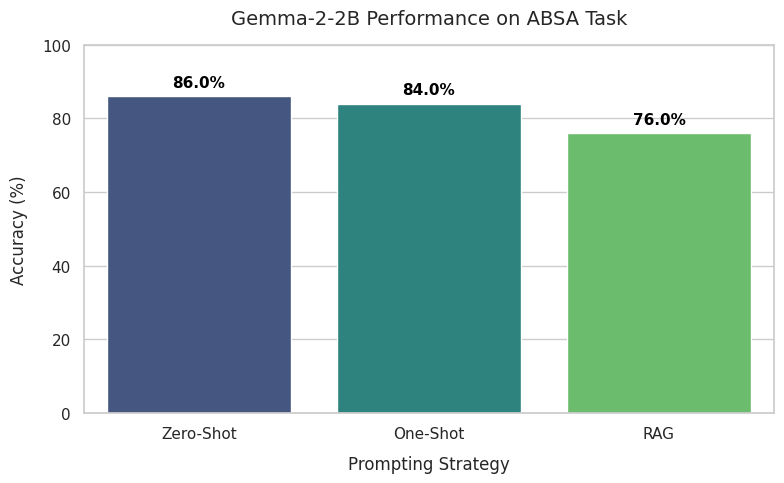

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# results list -> DataFrame
df = pd.DataFrame(gemma_results)

# plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# bar chart
ax = sns.barplot(
    x="Method",
    y="Accuracy",
    data=df,
    hue="Method",
    palette="viridis",
    legend=False
)

# axes and labels
plt.title("Gemma-2-2B Performance on ABSA Task", fontsize=14, pad=15)
plt.xlabel("Prompting Strategy", fontsize=12, labelpad=10)
plt.ylabel("Accuracy (%)", fontsize=12, labelpad=10)
plt.ylim(0, 100)  # y-axis 0-100

# accuracy labels on bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, -15) if p.get_height() > 90 else (0, 10),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold',
                color='black')

plt.tight_layout()
plt.show()